## 🤖 Machine Learning Multi-Factor Price Prediction Model
###### This model applies professional quantitative finance techniques and machine learning to predict future stock price direction and returns in the Brazilian equity market. It combines momentum, volatility, trend, mean reversion, and volume-based factors into a multi-factor feature set, then uses LightGBM ensemble learning with walk-forward validation to identify statistically significant market patterns and generate directional trading signals.

<div style="font-size:12px">

| Feature | Quant |
|---|---|
| Log Return | Stationary |
| Volatility | Risk |
| Momentum | Alpha |
| Z-Score | Mean Rev |
| Walk-Forward | OOS |
| LightGBM | Ensemble |
| Sharpe | Risk Adj |

</div>

In [129]:
import warnings, numpy as np, pandas as pd, yfinance as yf, matplotlib.pyplot as plt, ta
warnings.filterwarnings("ignore")

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


In [130]:
ticker = "TOTS3.SA"
df = yf.download(ticker, start="2015-01-01", auto_adjust=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_cols:
    df[col] = pd.Series(df[col].values.flatten(), index=df.index)

df = df.dropna()

[*********************100%***********************]  1 of 1 completed


In [131]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) # daily log return
df["target"] = df["log_return"].shift(-5) # attempt to predict return in 5 sessions
df["volatility_20"] = (df["log_return"].rolling(20).std()) # vol. for 20 sessions 
df["momentum_10"] = (df["Close"] / df["Close"].shift(10)) - 1 # momentum is the strength of the recent trend (n = 10 and 30 sessions)
df["momentum_30"] = (df["Close"] / df["Close"].shift(30)) - 1
df["zscore_20"] = ((df["Close"] - df["Close"].rolling(20).mean())/df["Close"].rolling(20).std()) # mean distance
df["rsi"] = ta.momentum.RSIIndicator(close=df["Close"], window=14).rsi() # Relative Strength Index
df["atr"] = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["Close"], window=14).average_true_range() # avg amplitude

macd = ta.trend.MACD(df["Close"]) # dif. between exponential avgs.
df["macd"] = macd.macd() 
df["macd_signal"] = macd.macd_signal()

df["volume_zscore"] = ((df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()) # standardized volume

df = df.dropna()

##### Z-Score:
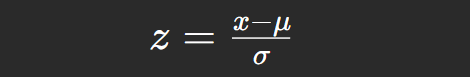

In [132]:
features = [
    "volatility_20",
    "momentum_10",
    "momentum_30",
    "zscore_20",
    "rsi",
    "atr",
    "macd",
    "macd_signal",
    "volume_zscore"
]

X = df[features] # observation
y = df["target"]

In [133]:
tscv = TimeSeriesSplit(n_splits=5) # walk-forward validation

predictions = []
real_values = []

In [134]:
for train_idx, test_idx in tscv.split(X): # validation loop
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler() # statistical normalization

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)

    model.fit(X_train, y_train) # LGBM learns non-linear relationships between factors and returns

    preds = model.predict(X_test)

    predictions.extend(preds)
    real_values.extend(y_test)

In [135]:
predictions = np.array(predictions)  
real_values = np.array(real_values)  

rmse = np.sqrt(mean_squared_error(real_values, predictions))  # Calculate prediction error magnitude

directional_accuracy = np.mean(np.sign(predictions) == np.sign(real_values))  # Measure directional prediction accuracy

strategy_returns = (np.sign(predictions) * real_values)  # Simulate directional trading returns

sharpe_ratio = ((strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252))  # Calculate annualized risk-adjusted return

In [136]:
latest_data = X.iloc[-1:]
latest_scaled = scaler.transform(latest_data)
forecast = model.predict(latest_scaled)[0]

In [137]:
# If the model predicts an increase greater than 2% in the next 5 days
if forecast > 0.02:
    signal = "LONG"
elif forecast < -0.02:
    signal = "SHORT"
else:
    signal = "NEUTRAL"

print(f"Predicted 5D Return: {forecast:.4%}")
print('------------------------------')
print(f"RMSE: {rmse:.6f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print('------------------------------')
print(f"Signal: {signal}")

Predicted 5D Return: -1.5443%
------------------------------
RMSE: 0.024813
Directional Accuracy: 48.65%
Sharpe Ratio: -0.32
------------------------------
Signal: NEUTRAL
